# Chapter 17 computational laboratory: PoE, PoIE, and PoPE on Gaussian models

This notebook builds an exactly solvable continuous benchmark for the three composition notions introduced in Chapter 17.

We compare:

1. **PoE:** multiply terminal densities;
2. **PoIE:** multiply independently smoothed one-time marginals at every artificial time;
3. **PoPE:** multiply complete path laws and only then marginalize the product path law to its endpoint.

Gaussian models are useful here because every normalization, score, product, and marginal can be computed analytically. The notebook is not meant to claim that all diffusion models are Gaussian. Its purpose is to isolate the algebraic distinction among the three compositions before neural approximation is introduced.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Ellipse

FIGDIR = Path("figs")
FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def gaussian_product(mus, covs, betas):
    J = sum(b * np.linalg.inv(S) for b, S in zip(betas, covs))
    h = sum(b * np.linalg.solve(S, m) for b, S, m in zip(betas, covs, mus))
    S = np.linalg.inv(J)
    m = S @ h
    return m, S

def smooth_gaussian(mu, cov, alpha):
    # x_t = alpha x_1 + sqrt(1-alpha^2) z, z ~ N(0,I)
    return alpha * mu, alpha**2 * cov + (1 - alpha**2) * np.eye(len(mu))

def add_cov_ellipse(ax, mu, cov, label, nstd=1.8, linestyle='-'):
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * nstd * np.sqrt(vals)
    e = Ellipse(mu, width, height, angle=angle, fill=False, linewidth=2.5, linestyle=linestyle, label=label)
    ax.add_patch(e)
    ax.scatter(*mu, s=55)


## 1. Space--time graphical structure

A dynamic graphical model has two kinds of dependencies: spatial edges inside each state $x_t$ and temporal edges between states at consecutive times. The following figure deliberately emphasizes this two-dimensional structure.

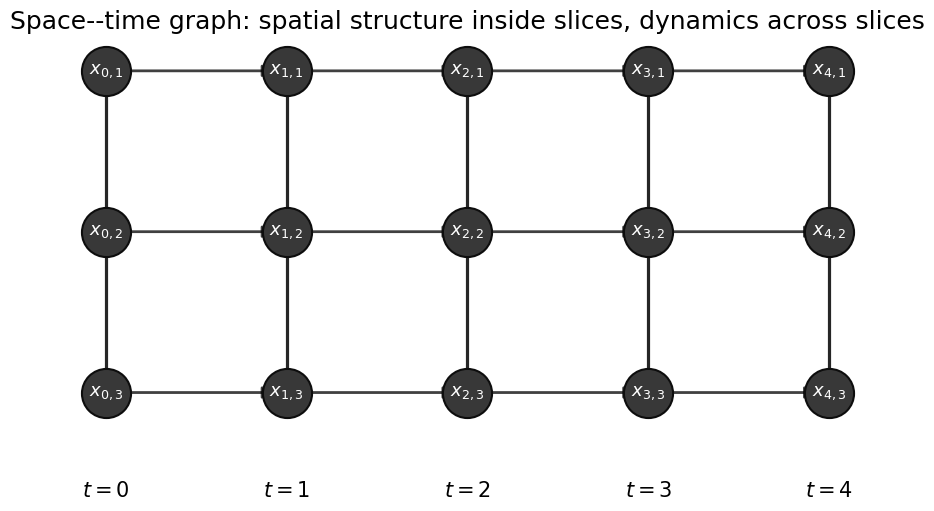

In [2]:
T = 4
G = nx.DiGraph()
pos = {}
for t in range(T + 1):
    for i in range(3):
        node = (t, i)
        G.add_node(node)
        pos[node] = (t, 2-i)
        if i > 0:
            G.add_edge((t, i-1), node, kind="spatial")
        if t > 0:
            G.add_edge((t-1, i), node, kind="temporal")

fig, ax = plt.subplots(figsize=(9.2, 5.4))
spatial = [(u,v) for u,v,d in G.edges(data=True) if d['kind']=='spatial']
temporal = [(u,v) for u,v,d in G.edges(data=True) if d['kind']=='temporal']
nx.draw_networkx_nodes(G, pos, node_size=1250, node_color="0.22", edgecolors="0.05", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, labels={n: rf"$x_{{{n[0]},{n[1]+1}}}$" for n in G.nodes}, font_color="white", font_size=13, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=spatial, width=2.3, arrows=False, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=temporal, width=2.0, arrows=True, arrowstyle="-|>", arrowsize=17, alpha=0.75, ax=ax)
for t in range(T+1):
    ax.text(t, -0.55, rf"$t={t}$", ha="center", va="top", fontsize=15)
ax.set_title("Space--time graph: spatial structure inside slices, dynamics across slices")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(FIGDIR / "ch17_01_space_time_graph.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "ch17_01_space_time_graph.png", dpi=220, bbox_inches="tight")
plt.show()


## 2. PoE versus PoIE under a common Gaussian noising map

Take two terminal experts

$$
p_1^k = \mathcal N(\mu_k,\Sigma_k), \qquad k=1,2,
$$

and a common noising interpolation

$$
x_t = \alpha_t x_1 + \sqrt{1-\alpha_t^2}\,z, \qquad z\sim\mathcal N(0,I),
$$

with $\alpha_0=0$ and $\alpha_1=1$.

The terminal PoE is Gaussian because products of Gaussian densities are Gaussian. We can either:

- form the terminal PoE and then noise that product; or
- noise each expert separately and multiply the intermediate marginals, producing PoIE.

These two operations generally do not commute.

In [3]:
mu1 = np.array([-1.2, 0.4])
mu2 = np.array([1.0, -0.5])
S1 = np.array([[1.4, 0.55], [0.55, 0.8]])
S2 = np.array([[0.75, -0.30], [-0.30, 1.25]])
betas = np.array([0.55, 0.45])  # B=1 gives a common N(0,I) PoIE start

mu_poe, S_poe = gaussian_product([mu1, mu2], [S1, S2], betas)

ts = np.linspace(0, 1, 81)
mean_gap, cov_gap = [], []
poie_path = []
noised_poe_path = []
for t in ts:
    alpha = t
    m1t, S1t = smooth_gaussian(mu1, S1, alpha)
    m2t, S2t = smooth_gaussian(mu2, S2, alpha)
    m_poie, S_poie = gaussian_product([m1t, m2t], [S1t, S2t], betas)
    m_true, S_true = smooth_gaussian(mu_poe, S_poe, alpha)
    poie_path.append((m_poie, S_poie))
    noised_poe_path.append((m_true, S_true))
    mean_gap.append(np.linalg.norm(m_poie - m_true))
    cov_gap.append(np.linalg.norm(S_poie - S_true, ord='fro'))

print("Initial PoIE mean:", poie_path[0][0])
print("Initial PoIE covariance:\n", poie_path[0][1])
print("Terminal PoIE/PoE mean gap:", mean_gap[-1])
print("Terminal PoIE/PoE covariance gap:", cov_gap[-1])
assert np.allclose(poie_path[0][0], 0, atol=1e-10)
assert np.allclose(poie_path[0][1], np.eye(2), atol=1e-10)
assert mean_gap[-1] < 1e-10 and cov_gap[-1] < 1e-10


Initial PoIE mean: [0. 0.]
Initial PoIE covariance:
 [[1. 0.]
 [0. 1.]]
Terminal PoIE/PoE mean gap: 0.0
Terminal PoIE/PoE covariance gap: 0.0


The common start in this example is not automatic for arbitrary exponents. If all component starts are $\mathcal N(0,I)$ and $B=\sum_k\beta_k$, their product is proportional to

$$
\exp\left(-\frac{B}{2}\|x\|^2\right),
$$

so the normalized PoIE start is $\mathcal N(0,B^{-1}I)$. We chose $B=1$ here.

## 3. PoPE: multiply complete Gaussian path laws

To obtain a genuinely path-level composition, we now use two linear-Gaussian Markov processes

$$
x_{t+1}=A_k x_t+b_k+\varepsilon_t, \qquad \varepsilon_t\sim\mathcal N(0,Q).
$$

Each expert defines a joint Gaussian law over $X=(x_0,\ldots,x_T)$. Multiplying the complete joint densities and normalizing gives another joint Gaussian. We then marginalize that product path law to $x_T$.

This endpoint is generally different from the product of the two endpoint marginals because PoPE combines all cross-time dependencies before marginalization.

In [4]:
def path_moments(A, b, Q, T):
    d = len(b)
    means = [np.zeros(d)]
    covs = [np.eye(d)]
    cross = {}
    for t in range(T):
        means.append(A @ means[-1] + b)
        covs.append(A @ covs[-1] @ A.T + Q)
    # Build the full covariance using Cov(x_s,x_t)=Cov(x_s) (A^{t-s})^T for s<t.
    n = (T+1)*d
    mu = np.concatenate(means)
    S = np.zeros((n,n))
    for s in range(T+1):
        for t in range(T+1):
            if s <= t:
                Apow = np.linalg.matrix_power(A, t-s)
                block = covs[s] @ Apow.T
            else:
                Apow = np.linalg.matrix_power(A, s-t)
                block = Apow @ covs[t]
            S[s*d:(s+1)*d, t*d:(t+1)*d] = block
    return mu, S

Tp = 4
d = 2
Q = 0.22*np.eye(d)
A1 = np.array([[0.86, 0.16], [-0.04, 0.78]])
A2 = np.array([[0.72, -0.18], [0.10, 0.90]])
b1 = np.array([0.25, -0.04])
b2 = np.array([-0.12, 0.19])

mu_path1, S_path1 = path_moments(A1,b1,Q,Tp)
mu_path2, S_path2 = path_moments(A2,b2,Q,Tp)
mu_pope_path, S_pope_path = gaussian_product([mu_path1,mu_path2],[S_path1,S_path2],betas)
mu_pope_T = mu_pope_path[-d:]
S_pope_T = S_pope_path[-d:,-d:]

mu_T1, S_T1 = mu_path1[-d:], S_path1[-d:,-d:]
mu_T2, S_T2 = mu_path2[-d:], S_path2[-d:,-d:]
mu_endpoint_poe, S_endpoint_poe = gaussian_product([mu_T1,mu_T2],[S_T1,S_T2],betas)

print("Endpoint PoE mean:", mu_endpoint_poe)
print("PoPE terminal mean:", mu_pope_T)
print("Mean difference:", np.linalg.norm(mu_pope_T-mu_endpoint_poe))
print("Covariance difference:", np.linalg.norm(S_pope_T-S_endpoint_poe,ord='fro'))
assert np.linalg.norm(mu_pope_T-mu_endpoint_poe) > 1e-3


Endpoint PoE mean: [ 0.15968057 -0.0477028 ]
PoPE terminal mean: [ 0.0998811  -0.09683035]
Mean difference: 0.07739181344300036
Covariance difference: 0.13465188609296552


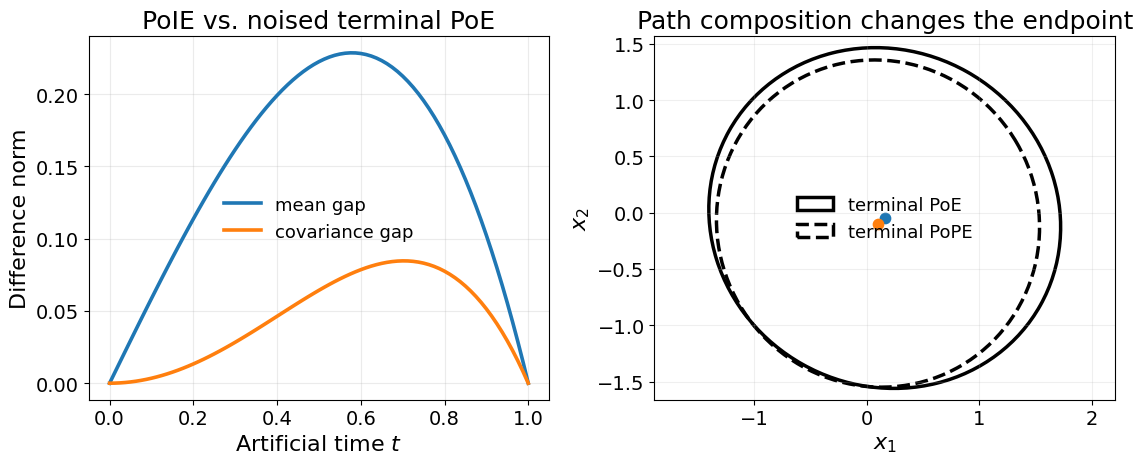

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.9))
axes[0].plot(ts, mean_gap, linewidth=2.6, label="mean gap")
axes[0].plot(ts, cov_gap, linewidth=2.6, label="covariance gap")
axes[0].set_xlabel("Artificial time $t$")
axes[0].set_ylabel("Difference norm")
axes[0].set_title("PoIE vs. noised terminal PoE")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

add_cov_ellipse(axes[1], mu_endpoint_poe, S_endpoint_poe, "terminal PoE")
add_cov_ellipse(axes[1], mu_pope_T, S_pope_T, "terminal PoPE", linestyle="--")
axes[1].set_title("Path composition changes the endpoint")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].axis("equal")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(FIGDIR / "ch17_01_composition_comparison.pdf", bbox_inches="tight")
fig.savefig(FIGDIR / "ch17_01_composition_comparison.png", dpi=220, bbox_inches="tight")
plt.show()


## What the Gaussian benchmark establishes

The notebook makes three points without approximation:

1. **PoE is an endpoint object.** It says nothing by itself about intermediate-time marginals.
2. **PoIE preserves product structure at every slice.** With a common noising map, this is convenient because its score is a weighted sum of component scores, but the PoIE path generally differs from noising the terminal PoE.
3. **PoPE is a path object.** Multiplying complete trajectory laws also combines temporal correlations, so its endpoint generally differs from the terminal PoE.

These distinctions remain after the Gaussian assumption is removed. What becomes difficult in nonlinear generative models is computing the respective normalizers, scores, or path corrections.

## Exercises and research challenges

1. Change the exponents so $B\neq 1$ and verify that the initial PoIE covariance becomes $B^{-1}I$.
2. Force the two path experts to share the same transition matrix and noise but use different drifts. Under which parameter choices does the PoPE endpoint approach the terminal PoE?
3. Replace one terminal Gaussian by a two-component Gaussian mixture. Numerically evaluate the PoIE marginals and compare them with noising the terminal PoE.
4. **Challenge:** formulate the same three compositions for a discrete Ising chain using a discrete noising process. This is the natural bridge to discrete Feynman--Kac correction and Sampling Decisions.